In [1]:
import torch
a = torch.tensor([1.0])
a.requires_grad = True # 或者 a.requires_grad_()
print(a)
print(a.data)
print(a.type())             # a的类型是tensor
print(a.data.type())        # a.data的类型是tensor
print(a.grad)
print(type(a.grad))
# 对于每一个tensor节点，包含data和grad属性

tensor([1.], requires_grad=True)
tensor([1.])
torch.FloatTensor
torch.FloatTensor
None
<class 'NoneType'>


In [2]:
import torch
x_data = [1.0, 2.0, 3.0]
y_data = [2.0, 4.0, 6.0]
 
w = torch.tensor([1.0]) # w的初值为1.0
w.requires_grad = True # 需要计算梯度
 
def forward(x):
    return x*w  # w是一个Tensor
 
 
def loss(x, y):
    y_pred = forward(x)
    return (y_pred - y)**2

# forward()和loss()都是计算图的一部分，计算图是pytorch自动构建的，不需要我们手动构建，这两个函数是在构建计算图
 
print("predict (before training)", 4, forward(4).item())
 
for epoch in range(100):
    for x, y in zip(x_data, y_data):
        l =loss(x,y) # l是一个张量，tensor主要是在建立计算图 forward, compute the loss
        l.backward() #  backward,compute grad for Tensor whose requires_grad set to True
        print('\tgrad:', x, y, w.grad.item())    # .item() 将tensor转换为标量
        w.data = w.data - 0.01 * w.grad.data   # 权重更新时，注意grad也是一个tensor
 
        w.grad.data.zero_() 
        # after update, remember set the grad to zero, 每进行一次反向传播，梯度清零，否则会累加，导致梯度爆炸
        # 有时候需要梯度累加，所以也有不用清零的情况
 
    print('progress:', epoch, l.item()) # 取出loss使用l.item，不要直接使用l（l是tensor会构建计算图）
 
print("predict (after training)", 4, forward(4).item())

predict (before training) 4 4.0
	grad: 1.0 2.0 -2.0
	grad: 2.0 4.0 -7.840000152587891
	grad: 3.0 6.0 -16.228801727294922
progress: 0 7.315943717956543
	grad: 1.0 2.0 -1.478623867034912
	grad: 2.0 4.0 -5.796205520629883
	grad: 3.0 6.0 -11.998146057128906
progress: 1 3.9987640380859375
	grad: 1.0 2.0 -1.0931644439697266
	grad: 2.0 4.0 -4.285204887390137
	grad: 3.0 6.0 -8.870372772216797
progress: 2 2.1856532096862793
	grad: 1.0 2.0 -0.8081896305084229
	grad: 2.0 4.0 -3.1681032180786133
	grad: 3.0 6.0 -6.557973861694336
progress: 3 1.1946394443511963
	grad: 1.0 2.0 -0.5975041389465332
	grad: 2.0 4.0 -2.3422164916992188
	grad: 3.0 6.0 -4.848389625549316
progress: 4 0.6529689431190491
	grad: 1.0 2.0 -0.4417421817779541
	grad: 2.0 4.0 -1.7316293716430664
	grad: 3.0 6.0 -3.58447265625
progress: 5 0.35690122842788696
	grad: 1.0 2.0 -0.3265852928161621
	grad: 2.0 4.0 -1.2802143096923828
	grad: 3.0 6.0 -2.650045394897461
progress: 6 0.195076122879982
	grad: 1.0 2.0 -0.24144840240478516
	grad: 2.

### homework

True
1
Epoch  300/3000, Loss: 1.958838
Epoch  600/3000, Loss: 1.501238
Epoch  900/3000, Loss: 1.234684
Epoch 1200/3000, Loss: 1.077977
Epoch 1500/3000, Loss: 0.985849
Epoch 1800/3000, Loss: 0.931688
Epoch 2100/3000, Loss: 0.899847
Epoch 2400/3000, Loss: 0.881128
Epoch 2700/3000, Loss: 0.870123
Epoch 3000/3000, Loss: 0.863653


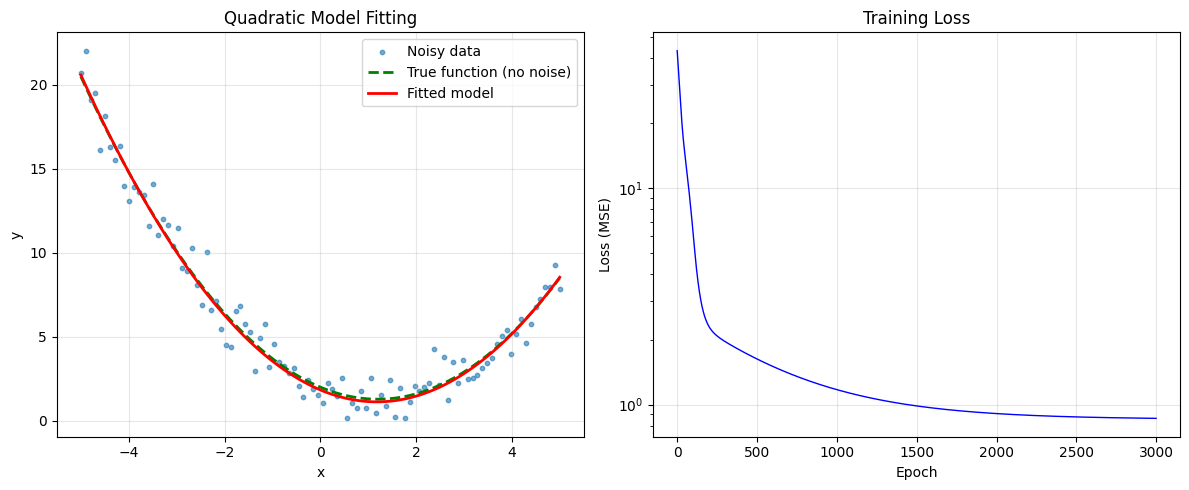


Final parameters:
  w1 (learned) = 0.5095  (true: 0.5)
  w2 (learned) = -1.2052  (true: -1.2)
  b  (learned) = 1.8335  (true: 2.0)


In [ ]:
# Quadratic Model: y_pred = w1*x^2 + w2*x + b
# Loss Function: L = (y_pred - y)^2 = (w1*x^2 + w2*x + b - y)^2
# compute the gradient of w1, w2 and b using pytorch
import torch
import matplotlib.pyplot as plt
import numpy as np

print(torch.cuda.is_available())
print(torch.cuda.device_count())
# ------------------------------
# 1. 生成模拟数据（真实二次函数 + 噪声）
# ------------------------------
torch.manual_seed(42)   # 固定随机种子，便于复现

# 真实参数（用来生成数据）
true_w1 = 0.5
true_w2 = -1.2
true_b = 2.0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# 构造一组带噪声的二次函数回归数据
# torch.linspace(-5, 5, 100)：在区间 [-5, 5] 上等间距取 100 个点。默认得到一维张量，形状是 (100,)。
# 使用 reshape(-1, 1) 将其变形为列向量，形状为 (100, 1)
x = torch.linspace(-5, 5, 100).reshape(-1, 1).to(device)
y_true = true_w1 * x**2 + true_w2 * x + true_b

# * 1.0：把噪声标准差缩放为 1.0（这里乘 1.0 数值不变，但语义上是“噪声强度”）。
noise = torch.randn_like(y_true) * 1.0
y = y_true + noise

# 需要梯度的参数
w1 = torch.tensor(0.2, requires_grad=True, device=device)    # 0.2 是初始值，需要梯度
w2 = torch.tensor(0.2, requires_grad=True, device=device)
b = torch.tensor(0.0, requires_grad=True, device=device)

# ------------------------------
# 2. 训练配置
# ------------------------------
learning_rate = 0.001   
num_epochs = 3000
losses = []

def forward(x):
    return w1 * x**2 + w2 * x + b

def loss(x, y):
    y_pred = forward(x)
    return ((y_pred - y) ** 2).mean()  # 原本返回的是一个张量，形状为(100,1)，这里使用mean()将其转换为标量 MSE，backward 才能稳定执行

# ------------------------------
# 3. 训练循环
# ------------------------------
for epoch in range(num_epochs):
    l = loss(x, y)

    # 如果出现 nan/inf，立刻停止并提示
    if not torch.isfinite(l):
        raise RuntimeError(f"Loss became non-finite at epoch {epoch}: {l.item()}")

    l.backward()

    # 手动更新参数（不使用优化器，便于理解）
    with torch.no_grad():
        # 梯度裁剪，防止梯度过大导致参数爆炸
        torch.nn.utils.clip_grad_norm_([w1, w2, b], max_norm=10.0)

        w1 -= learning_rate * w1.grad
        w2 -= learning_rate * w2.grad
        b -= learning_rate * b.grad

        # 梯度清零，否则下次会累加
        w1.grad.zero_()
        w2.grad.zero_()
        b.grad.zero_()

    losses.append(l.item())

    if (epoch + 1) % 300 == 0:
        print(f"Epoch {epoch+1:4d}/{num_epochs}, Loss: {l.item():.6f}")

# 训练结束后再算一次预测，避免 y_pred 未定义或过期
with torch.no_grad():
    y_pred = forward(x)

# ------------------------------
# 4. 可视化拟合结果
# ------------------------------
x_np = x.detach().cpu().numpy().flatten()
y_np = y.detach().cpu().numpy().flatten()
y_pred_np = y_pred.detach().cpu().numpy().flatten()
y_true_np = y_true.detach().cpu().numpy().flatten()

plt.figure(figsize=(12, 5))

# 子图 1：数据点与拟合曲线
plt.subplot(1, 2, 1)
plt.scatter(x_np, y_np, s=10, alpha=0.6, label='Noisy data')
plt.plot(x_np, y_true_np, 'g--', linewidth=2, label='True function (no noise)')
plt.plot(x_np, y_pred_np, 'r-', linewidth=2, label='Fitted model')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Quadratic Model Fitting')
plt.legend()
plt.grid(alpha=0.3)

# 子图 2：损失下降曲线
plt.subplot(1, 2, 2)
plt.plot(losses, 'b-', linewidth=1)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training Loss')
plt.grid(alpha=0.3)
plt.yscale('log')

plt.tight_layout()
plt.show()

# 打印最终学习到的参数
print("\nFinal parameters:")
print(f"  w1 (learned) = {w1.item():.4f}  (true: {true_w1})")
print(f"  w2 (learned) = {w2.item():.4f}  (true: {true_w2})")
print(f"  b  (learned) = {b.item():.4f}  (true: {true_b})")
